In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline



df_clean = pd.read_csv("data_cleaned.csv")
print(df_clean.shape)

(125973, 124)


In [2]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [3]:
def compute_cost(X,y,w,b):
    m=len(y)
    z=np.dot(X,w) + b
    predctions = sigmoid(z)
    epsilon = 1e-9
    cost= -(1/m) * np.sum(y * np.log(predctions+epsilon) + (1-y)*np.log(1-predctions+epsilon))
    return cost


In [4]:
print(sigmoid(0))
print(sigmoid(10))
print(sigmoid(-10))

0.5
0.9999546021312976
4.5397868702434395e-05


In [5]:
def gradiant_descent(X,y,w,b,learning_rate,iterations):
    m=len(y)
    cost_history = []
    for i in range(iterations):
        z=np.dot(X,w) + b
        predctions=sigmoid(z)

        dw=(1/m)*np.dot(X.T,(predctions-y))
        db=(1/m)*np.sum(predctions-y)

        w -= learning_rate*dw
        b -= learning_rate*db

        cost_history.append(compute_cost(X,y,w,b))
        if i%100 == 0:
            print (f"Iteration{i}:cost={cost_history[-1]:.4f}")
    return w,b,cost_history    

     

        

In [6]:
X=df_clean.drop(columns='attack_flag').values
y=df_clean['attack_flag'].values

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

w = np.zeros(X_train.shape[1])
b=0
w,b,cost_history=gradiant_descent(X_train,y_train,w,b,learning_rate=0.1,iterations=1000)


Iteration0:cost=0.5423
Iteration100:cost=0.0824
Iteration200:cost=0.0663
Iteration300:cost=0.0592
Iteration400:cost=0.0550
Iteration500:cost=0.0522
Iteration600:cost=0.0502
Iteration700:cost=0.0486
Iteration800:cost=0.0474
Iteration900:cost=0.0465


AttributeError: module 'matplotlib.pyplot' has no attribute 'Xlabel'

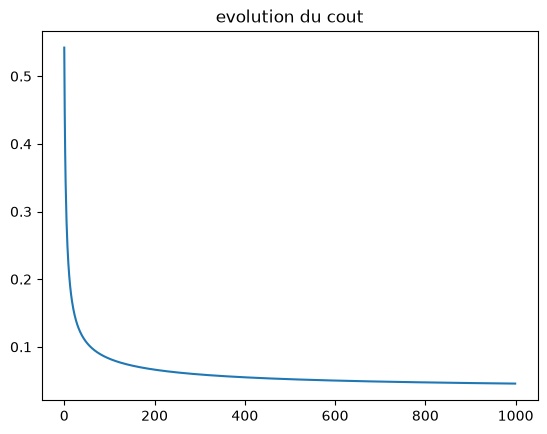

In [7]:
plt.plot(cost_history)
plt.title('evolution du cout')
plt.Xlabel('iterations')
plt.Ylabel('cout')
plt.show()